In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

sns.set_theme(style="whitegrid")

RUTA_CENSO_ZONAL = "/content/cc/Cartografía_censo2024_R13_Zonal.parquet"
RUTA_CENSO_COMUNAL = "/content/cc/Cartografía_censo2024_R13_Comunal.parquet"
SEED = 123

In [ ]:
censo_zonal = gpd.read_parquet(RUTA_CENSO_ZONAL).rename_geometry("geometry")

es_gran_santiago = (censo_zonal["PROVINCIA"] == "SANTIAGO") | (
    censo_zonal["COMUNA"].isin(["PUENTE ALTO", "SAN BERNARDO"])
)
censo_zonal = censo_zonal[es_gran_santiago].reset_index(drop=True)

censo_comunal = gpd.read_parquet(RUTA_CENSO_COMUNAL).rename_geometry("geometry")
censo_comunal = censo_comunal[
    (censo_comunal["PROVINCIA"] == "SANTIAGO") | (censo_comunal["COMUNA"].isin(["PUENTE ALTO", "SAN BERNARDO"]))
].reset_index(drop=True)

print(f"Zonas censales en Gran Santiago: {len(censo_zonal)}")
print(f"Comunas: {len(censo_comunal)}")

Zonas censales en Gran Santiago: 1642
Comunas: 34


In [ ]:
censo_zonal

,OBJECTID,CUT,COD_REGION,REGION,COD_PROVINCIA,PROVINCIA,COMUNA,AREA_C,DISTRITO,COD_DISTRITO,...,n_fuente_elect_otro,n_fuente_elect_no_tiene,n_basura_servicios,n_basura_entierra,n_basura_eriazo,n_basura_rio,n_basura_otro,SHAPE_Length,SHAPE_Area,geometry
0,2702,13107,13,METROPOLITANA DE SANTIAGO,131,SANTIAGO,HUECHURABA,URBANO,HUECHURABA,1,...,1.0,0.0,1397.0,1.0,1.0,0.0,0.0,0.055128,0.000085,"MULTIPOLYGON (((-70.67945 -33.34606, -70.67954..."
1,2703,13107,13,METROPOLITANA DE SANTIAGO,131,SANTIAGO,HUECHURABA,URBANO,HUECHURABA,1,...,1.0,0.0,1890.0,2.0,0.0,2.0,2.0,0.098319,0.000228,"MULTIPOLYGON (((-70.66177 -33.35015, -70.66179..."
2,2704,13107,13,METROPOLITANA DE SANTIAGO,131,SANTIAGO,HUECHURABA,URBANO,HUECHURABA,1,...,0.0,1.0,1535.0,3.0,2.0,0.0,0.0,0.032909,0.000052,"MULTIPOLYGON (((-70.684 -33.35198, -70.68411 -..."
3,2705,13107,13,METROPOLITANA DE SANTIAGO,131,SANTIAGO,HUECHURABA,URBANO,HUECHURABA,1,...,0.0,1.0,2167.0,0.0,0.0,0.0,5.0,0.060684,0.000139,"MULTIPOLYGON (((-70.6639 -33.35881, -70.6639 -..."
4,2706,13107,13,METROPOLITANA DE SANTIAGO,131,SANTIAGO,HUECHURABA,URBANO,HUECHURABA,1,...,1.0,2.0,1861.0,1.0,1.0,0.0,1.0,0.059381,0.000141,"MULTIPOLYGON (((-70.67542 -33.35296, -70.67568..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1637,4487,13123,13,METROPOLITANA DE SANTIAGO,131,SANTIAGO,PROVIDENCIA,URBANO,PEDRO DE VALDIVIA,2,...,0.0,0.0,1434.0,0.0,0.0,1.0,0.0,0.014824,0.000013,"MULTIPOLYGON (((-70.60952 -33.44183, -70.60948..."
1638,4488,13123,13,METROPOLITANA DE SANTIAGO,131,SANTIAGO,PROVIDENCIA,URBANO,HOSPITAL MILITAR,8,...,0.0,0.0,814.0,1.0,0.0,0.0,0.0,0.015632,0.000013,"MULTIPOLYGON (((-70.62259 -33.43018, -70.62235..."
1639,4526,13118,13,METROPOLITANA DE SANTIAGO,131,SANTIAGO,MACUL,URBANO,CAMINO AGRÍCOLA,4,...,0.0,1.0,1023.0,0.0,0.0,0.0,0.0,0.052187,0.000065,"MULTIPOLYGON (((-70.61641 -33.48493, -70.61661..."
1640,4902,13120,13,METROPOLITANA DE SANTIAGO,131,SANTIAGO,ÑUÑOA,URBANO,ESTADIO NACIONAL,8,...,1.0,1.0,837.0,0.0,0.0,0.0,0.0,0.053861,0.000098,"MULTIPOLYGON (((-70.60672 -33.46546, -70.60664..."


Construcción de indicadores

Debemos generar tasas en base a las variables que trae el parquet del censo.

In [ ]:
usable = (censo_zonal['n_per'] > 0) & (censo_zonal['n_vp_ocupada'] > 0)

censo_zonal = censo_zonal[usable].reset_index(drop=True)

In [ ]:
# Se generan los indicadores a usar para clusterizar

censo_zonal['pct_educ_sup']= (censo_zonal['n_cine_terciaria_maestria_doctorado']/censo_zonal['n_per'])*100
censo_zonal

,OBJECTID,CUT,COD_REGION,REGION,COD_PROVINCIA,PROVINCIA,COMUNA,AREA_C,DISTRITO,COD_DISTRITO,...,n_fuente_elect_no_tiene,n_basura_servicios,n_basura_entierra,n_basura_eriazo,n_basura_rio,n_basura_otro,SHAPE_Length,SHAPE_Area,geometry,pct_educ_sup
0,2702,13107,13,METROPOLITANA DE SANTIAGO,131,SANTIAGO,HUECHURABA,URBANO,HUECHURABA,1,...,0.0,1397.0,1.0,1.0,0.0,0.0,0.055128,0.000085,"MULTIPOLYGON (((-70.67945 -33.34606, -70.67954...",49.602178
1,2703,13107,13,METROPOLITANA DE SANTIAGO,131,SANTIAGO,HUECHURABA,URBANO,HUECHURABA,1,...,0.0,1890.0,2.0,0.0,2.0,2.0,0.098319,0.000228,"MULTIPOLYGON (((-70.66177 -33.35015, -70.66179...",48.201946
2,2704,13107,13,METROPOLITANA DE SANTIAGO,131,SANTIAGO,HUECHURABA,URBANO,HUECHURABA,1,...,1.0,1535.0,3.0,2.0,0.0,0.0,0.032909,0.000052,"MULTIPOLYGON (((-70.684 -33.35198, -70.68411 -...",31.917451
3,2705,13107,13,METROPOLITANA DE SANTIAGO,131,SANTIAGO,HUECHURABA,URBANO,HUECHURABA,1,...,1.0,2167.0,0.0,0.0,0.0,5.0,0.060684,0.000139,"MULTIPOLYGON (((-70.6639 -33.35881, -70.6639 -...",52.884894
4,2706,13107,13,METROPOLITANA DE SANTIAGO,131,SANTIAGO,HUECHURABA,URBANO,HUECHURABA,1,...,2.0,1861.0,1.0,1.0,0.0,1.0,0.059381,0.000141,"MULTIPOLYGON (((-70.67542 -33.35296, -70.67568...",42.631761
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1635,4487,13123,13,METROPOLITANA DE SANTIAGO,131,SANTIAGO,PROVIDENCIA,URBANO,PEDRO DE VALDIVIA,2,...,0.0,1434.0,0.0,0.0,1.0,0.0,0.014824,0.000013,"MULTIPOLYGON (((-70.60952 -33.44183, -70.60948...",55.485534
1636,4488,13123,13,METROPOLITANA DE SANTIAGO,131,SANTIAGO,PROVIDENCIA,URBANO,HOSPITAL MILITAR,8,...,0.0,814.0,1.0,0.0,0.0,0.0,0.015632,0.000013,"MULTIPOLYGON (((-70.62259 -33.43018, -70.62235...",65.035415
1637,4526,13118,13,METROPOLITANA DE SANTIAGO,131,SANTIAGO,MACUL,URBANO,CAMINO AGRÍCOLA,4,...,1.0,1023.0,0.0,0.0,0.0,0.0,0.052187,0.000065,"MULTIPOLYGON (((-70.61641 -33.48493, -70.61661...",27.467949
1638,4902,13120,13,METROPOLITANA DE SANTIAGO,131,SANTIAGO,ÑUÑOA,URBANO,ESTADIO NACIONAL,8,...,1.0,837.0,0.0,0.0,0.0,0.0,0.053861,0.000098,"MULTIPOLYGON (((-70.60672 -33.46546, -70.60664...",29.873418


In [ ]:
censo_zonal["pct_hacinamiento"] = censo_zonal["n_viv_hacinadas"] / censo_zonal["n_vp_ocupada"] * 100
censo_zonal["pct_dificultad_ver"] = censo_zonal["n_dificultad_ver"] / censo_zonal["n_per"] * 100
censo_zonal["pct_60_mas"] = censo_zonal["n_edad_60_mas"]/censo_zonal["n_per"]*100

indicadores = ["pct_educ_sup", "pct_60_mas", "pct_dificultad_ver"]
censo_zonal[indicadores].describe().round(1)

,pct_educ_sup,pct_60_mas,pct_dificultad_ver
count,1640.0,1640.0,1640.0
mean,28.4,20.4,4.0
std,17.7,6.6,1.7
min,0.0,0.0,0.0
25%,13.5,16.0,2.6
50%,23.4,21.3,4.0
75%,41.5,25.2,5.2
max,73.5,36.8,10.7


In [ ]:
censo_zonal["pct_dificultad_ver"].corr(censo_zonal["pct_educ_sup"])

np.float64(-0.7997723200592698)

In [ ]:
# En otras palabras existe una fuerte correlación negativa, lo que implica que a más pctje de profesionales hayan, menos ciegos habrán

In [ ]:
censo_zonal["pct_dificultad_ver"].corr(censo_zonal["pct_60_mas"])

np.float64(0.27831223809251016)

In [ ]:
censo_zonal["pct_60_mas"].corr(censo_zonal["pct_educ_sup"])

np.float64(-0.07580465006864404)

# ESCALAMIENTO

Se escalan las variables dado que puede pasar que las variables se encuentran a escalas (rangos) muy distintas y así evitar que una variable domine sobre la otra.

In [ ]:
X = censo_zonal[indicadores]
escalador = StandardScaler()
X_escalado = escalador.fit_transform(X)

### ¿Cuántos clústers?

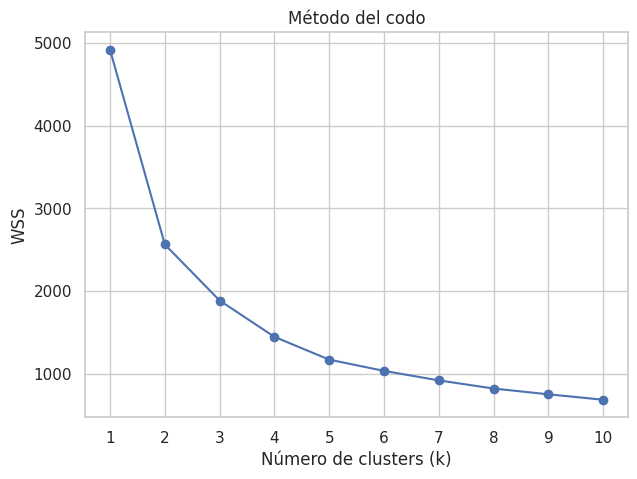

In [ ]:
wss = []
valores_k = range(1, 11)

for k in valores_k:
    modelo = KMeans(n_clusters=k, n_init=25, random_state=SEED)
    modelo.fit(X_escalado)
    wss.append(modelo.inertia_)

plt.figure(figsize=(7, 5))
plt.plot(valores_k, wss, marker="o")
plt.title("Método del codo")
plt.xlabel("Número de clusters (k)")
plt.ylabel("WSS")
plt.xticks(list(valores_k))
plt.show()

In [ ]:
# Se debe señalar por qué se elige un determinado número de cluster... justificar el codo.


# Se ejecuta K-means con k = 5
K = 5


kmeans = KMeans(n_clusters=K, n_init=25, random_state=SEED)
censo_zonal["cluster"] = kmeans.fit_predict(X_escalado).astype(str)

censo_zonal["cluster"].value_counts().sort_index()

,count
cluster,
0,263
1,304
2,443
3,255
4,375


## Visualizar los clústers

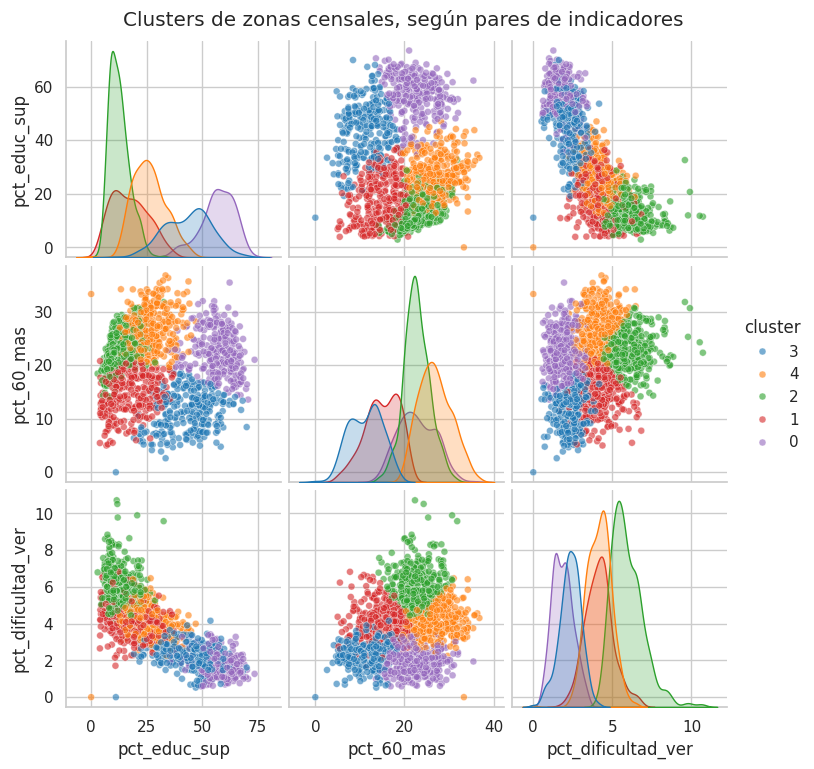

In [ ]:
sns.pairplot(
    censo_zonal,
    vars=indicadores,
    hue="cluster",
    palette="tab10",
    plot_kws={"alpha": 0.6, "s": 25},
    diag_kind="kde",
)
plt.suptitle("Clusters de zonas censales, según pares de indicadores", y=1.02)
plt.show()

In [ ]:
# rojos: difultad ver promedio, edad promedio baja, bajos profesionales
# verdes: muy alta dificultad ver, edad promedio, muy pocos profesionales
# azules: dificultad ver media-baja, edad muy baja, medio-alto profesionales
# naranjos:
# morado:

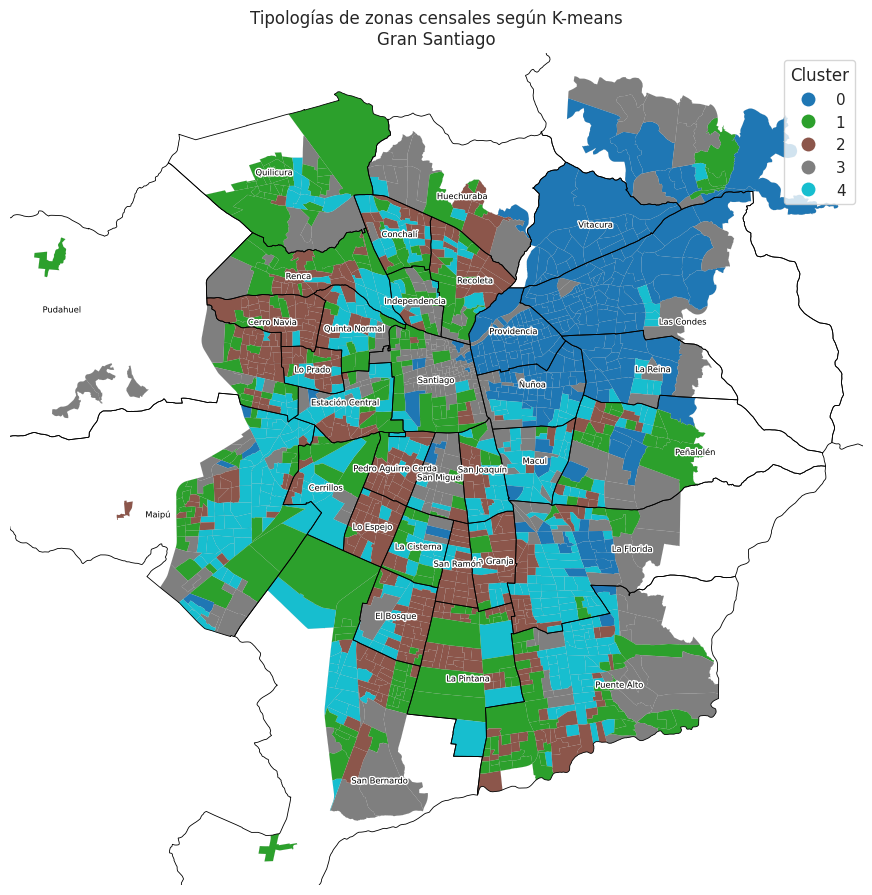

In [ ]:
fig, ax = plt.subplots(figsize=(11, 11))

censo_zonal.plot(
    column="cluster",
    categorical=True,
    cmap="tab10", # Acá se cambian los colores
    linewidth=0.05,
    edgecolor="grey",
    legend=True,
    legend_kwds={"title": "Cluster"},
    ax=ax,
)

# límites comunales encima, solo como referencia (sin relleno)
censo_comunal.boundary.plot(ax=ax, color="black", linewidth=0.6)

# nombre de cada comuna en su centroide, con un contorno blanco para que se lea
# encima de cualquier color de cluster
for _, fila in censo_comunal.iterrows():
    punto = fila.geometry.representative_point()
    ax.annotate(
        fila["COMUNA"].title(),
        xy=(punto.x, punto.y),
        ha="center", va="center",
        fontsize=6, color="black",
        path_effects=[pe.withStroke(linewidth=2, foreground="white")],
    )

ax.set_title("Tipologías de zonas censales según K-means\nGran Santiago")
ax.set_axis_off()

# recortamos la vista al área con zonas censales (no al límite comunal completo,
# que en algunas comunas se extiende vacío hacia la cordillera)
xmin, ymin, xmax, ymax = censo_zonal.total_bounds
margen_x = (xmax - xmin) * 0.03
margen_y = (ymax - ymin) * 0.03
ax.set_xlim(xmin - margen_x, xmax + margen_x)
ax.set_ylim(ymin - margen_y, ymax + margen_y)

plt.show()

In [ ]:
# qué tantos clusters tiene dentro de comuna, ejemp´lo: Vitacura baja dispersión, La Florida es heterogénea

In [ ]:
#Trabajo final: geolocalizar un servicio de manera inteligente.